<a href="https://colab.research.google.com/github/popcorn0125/Solar_energy_prediction/blob/main/AI_DX_EDU_%ED%83%9C%EC%96%91%EA%B4%91_%EC%A0%84%EB%A0%A5%EB%9F%89_%EC%98%88%EC%B8%A1_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EC%88%98%EC%A7%91.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.font_manager as fm

!apt-get update -qq
!apt-get install fonts-nanum

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
# (혹시 NanumBarunGothic이 없으면 NanumGothic.ttf 로 해보세요)
fm._load_fontmanager(try_read_cache = False)

font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name() # 폰트 이름 적용
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

print(f"설정된 폰트: {font_prop.get_name()}")
print('환경 설정 완료')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 54 not upgraded.
설정된 폰트: NanumGothic
환경 설정 완료


# 1. 데이터 수집: 대구 기상 관측 데이터 (ASOS)

이 단계에서는 기상청 공공데이터 포털의 API를 활용하여 **대구(지점코드: 143)** 지역의 2024년 1년 치 기상 데이터를 수집합니다.

###  수집 개요
* **데이터 출처**: 기상청 종관기상관측(ASOS) 시간자료 조회 서비스
* **수집 기간**: 2024.01.01 ~ 2024.12.31 (1년)
* **대상 지점**: 대구 (StnId: 143)
    * [사실] 대구의 기상 관측소 지점 번호는 143번입니다. (출처: 기상청 메타데이터)
* **주요 변수**: 일시, 기온, 강수량, 풍속, 습도, **일사량**, 전운량

###  주의사항
* `SERVICE_KEY` 변수에 본인의 **일반 인증키(Decoding)**를 반드시 입력해야 합니다.
* 하루 치 데이터가 아닌 월 단위로 반복 요청하여 서버 부하를 줄이고 안정성을 높입니다.

In [ ]:
from google.colab import userdata
asos_api_key = userdata.get('ASOS_API')

print('API 등록', asos_api_key)

In [ ]:
import requests

url = 'http://apis.data.go.kr/1360000/AsosHourlyInfoService/getWthrDataList'
params ={'serviceKey' : asos_api_key, 'pageNo' : '1', 'numOfRows' : '10', 'dataType' : 'XML', 'dataCd' : 'ASOS', 'dateCd' : 'HR', 'startDt' : '20100101', 'startHh' : '01', 'endDt' : '20100601', 'endHh' : '01', 'stnIds' : '108' }

response = requests.get(url, params=params)
print(response.content)

b'<?xml version="1.0" encoding="UTF-8"?>\r\n<response><header><resultCode>00</resultCode><resultMsg>NORMAL_SERVICE</resultMsg></header><body><dataType>XML</dataType><items><item><tm>2010-01-01 01:00</tm><rnum>1</rnum><stnId>108</stnId><stnNm>\xec\x84\x9c\xec\x9a\xb8</stnNm><ta>-11.0</ta><taQcflg>0</taQcflg><rn></rn><rnQcflg></rnQcflg><ws>1.2</ws><wsQcflg>0</wsQcflg><wd>290</wd><wdQcflg>0</wdQcflg><hm>45</hm><hmQcflg>0</hmQcflg><pv>1.2</pv><td>-20.6</td><pa>1012.5</pa><paQcflg>0</paQcflg><ps>1023.8</ps><psQcflg>0</psQcflg><ss></ss><ssQcflg>9</ssQcflg><icsr></icsr><dsnw>2.2</dsnw><hr3Fhsc></hr3Fhsc><dc10Tca></dc10Tca><dc10LmcsCa></dc10LmcsCa><clfmAbbrCd></clfmAbbrCd><lcsCh></lcsCh><vs></vs><gndSttCd></gndSttCd><dmstMtphNo></dmstMtphNo><ts>-6.5</ts><tsQcflg>0</tsQcflg><m005Te>-4.7</m005Te><m01Te>-2.1</m01Te><m02Te>-0.6</m02Te><m03Te>0.6</m03Te></item><item><tm>2010-01-01 02:00</tm><rnum>2</rnum><stnId>108</stnId><stnNm>\xec\x84\x9c\xec\x9a\xb8</stnNm><ta>-11.1</ta><taQcflg>0</taQcflg><rn>

In [ ]:
import requests
import pandas as pd
from urllib.parse import unquote
import time

# -----------------------------------------------------------
# [입력 필요] 공공데이터포털에서 발급받은 '일반 인증키(Decoding)'를 따옴표 안에 넣어주세요.
# -----------------------------------------------------------
SERVICE_KEY = asos_api_key

def get_daegu_weather_2024(api_key):
    """
    2024년 대구(143) 기상 데이터를 월별로 수집하여 통합하는 함수
    """
    base_url = "http://apis.data.go.kr/1360000/AsosHourlyInfoService/getWthrDataList"

    # 수집된 월별 데이터를 담을 리스트
    monthly_data_list = []

    print("데이터 수집을 시작합니다... (대구: 143, 대상 연도: 2024)")

    # 1월부터 12월까지 반복
    for month in range(1, 13):
        # 시작일과 종료일 계산 (예: 20240101 ~ 20240131)
        start_date = f"2024{month:02d}01"

        # 각 월의 마지막 날짜 계산 (간단한 로직)
        if month in [1, 3, 5, 7, 8, 10, 12]:
            last_day = 31
        elif month == 2:
            last_day = 29 # 2024년은 윤년
        else:
            last_day = 30

        end_date = f"2024{month:02d}{last_day}"

        # API 요청 변수 설정
        params = {
            'serviceKey': unquote(api_key),
            'pageNo': '1',
            'numOfRows': '999', # 한 달 최대 시간(744시간)보다 넉넉하게 설정
            'dataType': 'JSON',
            'dataCd': 'ASOS',
            'dateCd': 'HR',
            'startDt': start_date,
            'startHh': '00',
            'endDt': end_date,
            'endHh': '23',
            'stnIds': '143' # [사실] 대구 지점 코드
        }

        try:
            response = requests.get(base_url, params=params)
            data = response.json()

            # 응답 정상 확인
            if data['response']['header']['resultCode'] == '00':
                items = data['response']['body']['items']['item']
                df = pd.DataFrame(items)
                monthly_data_list.append(df)
                print(f"[성공] {month}월 데이터 {len(df)}개 수집 완료")
            else:
                msg = data['response']['header']['resultMsg']
                print(f"[실패] {month}월 데이터 요청 에러: {msg}")

        except Exception as e:
            print(f"[오류] {month}월 처리 중 예외 발생: {e}")

        # 서버 부하 방지를 위한 짧은 대기
        time.sleep(0.2)

    # 데이터 병합 및 저장
    if monthly_data_list:
        final_df = pd.concat(monthly_data_list, ignore_index=True)

        # 분석에 필요한 핵심 컬럼만 선택 및 이름 변경
        # tm:일시, ta:기온, rn:강수량, ws:풍속, hm:습도, icsr:일사량, dc10Tca:전운량
        cols_map = {
            'tm': '일시',
            'ta': '기온',
            'rn': '강수량',
            'ws': '풍속',
            'hm': '습도',
            'icsr': '일사량',
            'dc10Tca': '전운량'
        }

        # 존재하는 컬럼만 선택
        available_cols = [c for c in cols_map.keys() if c in final_df.columns]
        final_df = final_df[available_cols].rename(columns=cols_map)

        # 결측치(NaN) 처리: 강수량과 일사량의 빈 값은 0으로 채움 (맑은 날/밤)
        final_df['강수량'] = final_df['강수량'].fillna(0)
        final_df['일사량'] = final_df['일사량'].fillna(0)
        final_df['전운량'] = final_df['전운량'].fillna(0) # 구름 데이터가 비어있으면 맑음(0)으로 가정

        # CSV 저장
        filename = "/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/daegu_weather_2024.csv"
        final_df.to_csv(filename, index=False, encoding='utf-8-sig')

        print("-" * 50)
        print(f"[완료] 총 {len(final_df)}개의 데이터를 '{filename}' 파일로 저장했습니다.")
        print("데이터 미리보기:")
        print(final_df.head())

    else:
        print("[실패] 수집된 데이터가 없습니다. 인증키를 확인해주세요.")

# 함수 실행
if __name__ == "__main__":
    get_daegu_weather_2024(SERVICE_KEY)

데이터 수집을 시작합니다... (대구: 143, 대상 연도: 2024)
[성공] 1월 데이터 744개 수집 완료
[성공] 2월 데이터 696개 수집 완료
[성공] 3월 데이터 744개 수집 완료
[성공] 4월 데이터 720개 수집 완료
[성공] 5월 데이터 744개 수집 완료
[성공] 6월 데이터 720개 수집 완료
[성공] 7월 데이터 744개 수집 완료
[성공] 8월 데이터 744개 수집 완료
[성공] 9월 데이터 720개 수집 완료
[성공] 10월 데이터 744개 수집 완료
[성공] 11월 데이터 720개 수집 완료
[성공] 12월 데이터 744개 수집 완료
--------------------------------------------------
[완료] 총 8784개의 데이터를 '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/daegu_weather_2024.csv' 파일로 저장했습니다.
데이터 미리보기:
                 일시    기온 강수량   풍속  습도 일사량 전운량
0  2024-01-01 00:00   1.4      1.0  87       2
1  2024-01-01 01:00   0.8      0.7  91       0
2  2024-01-01 02:00   0.0      0.1  93       0
3  2024-01-01 03:00  -0.5      0.7  95       0
4  2024-01-01 04:00  -0.9      0.8  96       0


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/daegu_weather_2024.csv'
final_df = pd.read_csv(file_path, encoding='utf-8-sig')
print(final_df.info())
print(final_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   일시      8784 non-null   object 
 1   기온      8784 non-null   float64
 2   강수량     764 non-null    float64
 3   풍속      8784 non-null   float64
 4   습도      8784 non-null   int64  
 5   일사량     4809 non-null   float64
 6   전운량     8784 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 480.5+ KB
None
                 일시   기온  강수량   풍속  습도  일사량  전운량
0  2024-01-01 00:00  1.4  NaN  1.0  87  NaN    2
1  2024-01-01 01:00  0.8  NaN  0.7  91  NaN    0
2  2024-01-01 02:00  0.0  NaN  0.1  93  NaN    0
3  2024-01-01 03:00 -0.5  NaN  0.7  95  NaN    0
4  2024-01-01 04:00 -0.9  NaN  0.8  96  NaN    0


In [ ]:
import pandas as pd

# CSV 파일 불러오기 (이미 위에서 불러왔지만 명확화를 위해 다시 포함)
file_path = '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/daegu_weather_2024.csv'
final_df = pd.read_csv(file_path, encoding='utf-8-sig')

# '강수량'과 '일사량' 컬럼을 숫자로 변환하고 NaN을 0으로 채움
# errors='coerce'를 사용하여 숫자로 변환할 수 없는 값들은 NaN으로 만듦
final_df['강수량'] = pd.to_numeric(final_df['강수량'], errors='coerce').fillna(0)
final_df['일사량'] = pd.to_numeric(final_df['일사량'], errors='coerce').fillna(0)
final_df['전운량'] = pd.to_numeric(final_df['전운량'], errors='coerce').fillna(0)

print("결측치 처리 후 DataFrame 정보:")
final_df.info()

결측치 처리 후 DataFrame 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   일시      8784 non-null   object 
 1   기온      8784 non-null   float64
 2   강수량     8784 non-null   float64
 3   풍속      8784 non-null   float64
 4   습도      8784 non-null   int64  
 5   일사량     8784 non-null   float64
 6   전운량     8784 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 480.5+ KB


In [ ]:
# '일시' 컬럼을 datetime 형식으로 변환
final_df['일시'] = pd.to_datetime(final_df['일시'])

print("datetime 변환 후 DataFrame 정보:")
final_df.info()
print("\n변환 후 '일시' 컬럼 미리보기:")
print(final_df['일시'].head())

save_path = '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_daegu_weather_2024.csv'

final_df.to_csv(save_path, index=False, encoding='utf-8-sig')

datetime 변환 후 DataFrame 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   일시      8784 non-null   datetime64[ns]
 1   기온      8784 non-null   float64       
 2   강수량     8784 non-null   float64       
 3   풍속      8784 non-null   float64       
 4   습도      8784 non-null   int64         
 5   일사량     8784 non-null   float64       
 6   전운량     8784 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 480.5 KB

변환 후 '일시' 컬럼 미리보기:
0   2024-01-01 00:00:00
1   2024-01-01 01:00:00
2   2024-01-01 02:00:00
3   2024-01-01 03:00:00
4   2024-01-01 04:00:00
Name: 일시, dtype: datetime64[ns]


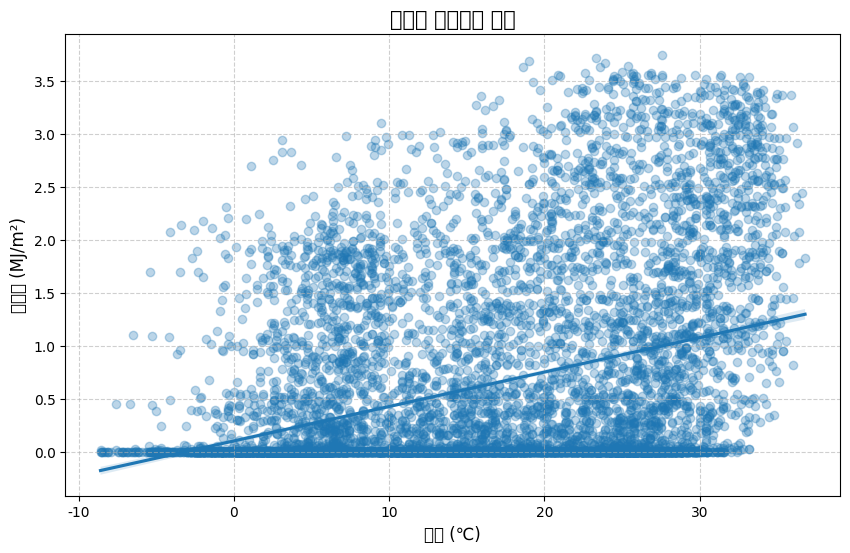

In [ ]:


# '기온'과 '일사량' 관계 시각화
plt.figure(figsize=(10, 6))
sns.regplot(x='기온', y='일사량', data=final_df, scatter_kws={'alpha':0.3})
plt.title('기온과 일사량의 관계', fontsize=15)
plt.xlabel('기온 (℃)', fontsize=12)
plt.ylabel('일사량 (MJ/m²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. 대구시 태양광 발전량 데이터 추출

이 단계에서는 업로드한 '전국 지역별 태양광 및 풍력 발전량' 파일에서 **대구시** 지역의 **태양광** 데이터만 추출하여 별도의 CSV 파일로 저장합니다.

###  수행 작업
1.  **데이터 로드**: 업로드된 `한국전력거래소_지역별 시간별 태양광 및 풍력 발전량...csv` 파일을 불러옵니다.
2.  **필터링 (Filtering)**:
    * **지역**: `대구시` (대구 지역 데이터만 선택)
    * **연료원**: `태양광` (풍력 데이터 제외)
3.  **데이터 저장**: 추출된 데이터를 `daegu_solar_2024.csv`라는 이름으로 저장하여, 이후 단계에서 가볍게 활용할 수 있도록 합니다.

###  준비물
* 좌측 파일 탭에 사용자가 업로드한 **한국전력거래소 CSV 파일**이 있어야 합니다.
* 파일 이름이 코드와 다를 경우, 코드 내의 `FILE_NAME` 변수를 수정해주세요.

In [ ]:
import pandas as pd
import os

# -----------------------------------------------------------
# [설정] 업로드한 파일명을 정확히 입력해주세요.
# -----------------------------------------------------------
FILE_NAME = '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/한국전력거래소_지역별 시간별 태양광 및 풍력 발전량_20241231.csv'

def extract_daegu_solar_data():
    # 1. 파일 존재 여부 확인
    if not os.path.exists(FILE_NAME):
        print(f"[오류] '{FILE_NAME}' 파일이 없습니다. 파일명을 확인하거나 업로드해주세요.")
        return

    # 2. 데이터 로드 (인코딩 에러 방지)
    print("데이터를 불러오는 중입니다...")
    try:
        # 공공데이터는 주로 cp949(euc-kr) 인코딩을 사용합니다.
        df = pd.read_csv(FILE_NAME, encoding='cp949')
    except UnicodeDecodeError:
        # cp949가 아니면 utf-8로 시도
        df = pd.read_csv(FILE_NAME, encoding='utf-8')

    # 3. 데이터 필터링: '대구시' & '태양광'
    # [사실] 데이터에는 '대구광역시'가 아닌 '대구시'로 표기되어 있습니다.
    target_region = '대구시'
    target_source = '태양광'

    # 필터링 조건 적용
    daegu_df = df[
        (df['지역'] == target_region) &
        (df['연료원'] == target_source)
    ].copy()

    # 데이터가 비어있다면 지역명 확인 안내
    if daegu_df.empty:
        print(f"[주의] 추출된 데이터가 없습니다. 지역명({target_region})이나 연료원({target_source})을 확인하세요.")
        print(f"데이터에 포함된 지역 목록: {df['지역'].unique()}")
        return

    # 4. 필요한 컬럼만 선택 및 정리
    # 거래일자, 거래시간, 전력거래량(MWh)만 남김
    daegu_df = daegu_df[['거래일자', '거래시간', '전력거래량(MWh)']]

    # 컬럼명 변경 (직관적으로)
    daegu_df.rename(columns={'전력거래량(MWh)': '발전량'}, inplace=True)

    # 5. CSV 파일로 저장
    save_filename = '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/daegu_solar_2024.csv'
    daegu_df.to_csv(save_filename, index=False, encoding='utf-8-sig')

    print("-" * 50)
    print(f"[완료] 대구시 태양광 데이터 추출 성공!")
    print(f"저장된 파일명: {save_filename}")
    print(f"추출된 데이터 개수: {len(daegu_df)}개")
    print("\n--- 데이터 미리보기 ---")
    print(daegu_df.head())


# 함수 실행
if __name__ == "__main__":
    extract_daegu_solar_data()

데이터를 불러오는 중입니다...
--------------------------------------------------
[완료] 대구시 태양광 데이터 추출 성공!
저장된 파일명: /content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/daegu_solar_2024.csv
추출된 데이터 개수: 8784개

--- 데이터 미리보기 ---
           거래일자  거래시간  발전량
120  2024-01-01     1  0.0
121  2024-01-01     2  0.0
122  2024-01-01     3  0.0
123  2024-01-01     4  0.0
124  2024-01-01     5  0.0


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/daegu_solar_2024.csv'
daegu_df = pd.read_csv(file_path, encoding='utf-8-sig')
print(daegu_df.info())
print(daegu_df.head())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   거래일자    8784 non-null   object 
 1   거래시간    8784 non-null   int64  
 2   발전량     8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 206.0+ KB
None
         거래일자  거래시간  발전량
0  2024-01-01     1  0.0
1  2024-01-01     2  0.0
2  2024-01-01     3  0.0
3  2024-01-01     4  0.0
4  2024-01-01     5  0.0


# 3. 데이터 병합: 기상 데이터(X) + 발전량 데이터(Y)

이 단계에서는 서로 다른 파일에 저장된 기상 데이터와 태양광 발전량 데이터를 **'일시'**를 기준으로 하나로 합칩니다. 이를 통해 머신러닝 모델이 학습할 수 있는 최종 데이터셋(`final_dataset_for_AI.csv`)을 생성합니다.

###  수행 작업
1.  **시간 동기화 (Time Synchronization)**:
    * `daegu_solar_2024.csv`의 `거래일자`와 `거래시간` 컬럼을 합쳐, 기상 데이터와 동일한 `YYYY-MM-DD HH:MM:SS` 형식의 `datetime` 객체로 변환합니다.
    * 예: 2024-01-01 (날짜) + 1 (시간) -> **2024-01-01 01:00:00**
2.  **데이터 병합 (Merge/Join)**:
    * 두 데이터프레임을 `일시` 컬럼을 기준으로 **Inner Join** (교집합)합니다. 날씨와 발전량 정보가 모두 존재하는 시간대만 남깁니다.
3.  **데이터 정제 (Cleaning)**:
    * **결측치 처리**: 병합 과정에서 발생할 수 있는 빈 값을 처리합니다.
    * **노이즈 제거**: 일사량이 0인 밤 시간대에 미세하게 잡힌 발전량(ESS 방전 등)을 0으로 보정하여 모델의 혼란을 방지합니다.
4.  **파생변수 추가 (Feature Engineering)**:
    * 모델이 계절과 시간의 주기성을 학습할 수 있도록 `월(Month)`, `시간(Hour)` 컬럼을 명시적으로 추가합니다.

###  결과물
* `final_dataset_for_AI.csv`: 전처리가 완료된 최종 학습용 데이터 파일.

In [ ]:
import pandas as pd
import numpy as np

# 파일명 설정
weather_file = '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction//final_daegu_weather_2024.csv'
solar_file = '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/daegu_solar_2024.csv'

def create_final_dataset():
    # 1. 데이터 로드
    print("데이터를 불러오는 중...")
    df_weather = pd.read_csv(weather_file)
    df_solar = pd.read_csv(solar_file)

    # 2. 기상 데이터 전처리
    # '일시' 컬럼을 문자열에서 datetime 객체로 변환
    df_weather['일시'] = pd.to_datetime(df_weather['일시'])

    # 3. 발전량 데이터 시간 형식 변환
    # 거래일자(String)를 datetime으로 변환
    df_solar['거래일자'] = pd.to_datetime(df_solar['거래일자'])

    # [중요] 거래일자에 거래시간(Hour)을 더해 '일시' 컬럼 생성
    # timedelta를 사용하면 24시도 다음날 00시로 자동 계산되어 안전합니다.
    # 예: 1시 -> 01:00:00 (기상 데이터 01:00와 매칭)
    df_solar['일시'] = df_solar['거래일자'] + pd.to_timedelta(df_solar['거래시간'], unit='h')

    # 불필요한 컬럼 제거 (거래일자, 거래시간, 지역, 연료원 등)
    df_solar = df_solar[['일시', '발전량']]

    # 4. 데이터 병합 (Inner Join)
    # 기상 데이터와 발전량 데이터를 '일시' 기준으로 합침
    print(f"병합 전 - 기상: {len(df_weather)}, 태양광: {len(df_solar)}")
    df_final = pd.merge(df_weather, df_solar, on='일시', how='inner')
    print(f"병합 후 - 최종 데이터: {len(df_final)}")

    # 5. 데이터 정제 (Data Cleaning)
    # [사실] 일사량이 0인 밤에는 태양광 발전이 불가능함.
    # 하지만 ESS 방전 등으로 인해 발전량이 0보다 크게 잡히는 경우가 있음. 이를 0으로 보정.
    # 일사량이 없거나(0), 전운량이 비정상적인 경우 등을 고려

    # 조건: 일사량이 0이거나 NaN인데 발전량이 0보다 큰 경우 -> 발전량을 0으로 강제
    # (참고: 기상청 일사량은 0 또는 NaN일 때 밤인 경우가 많음)
    mask_night = (df_final['일사량'].fillna(0) <= 0)
    df_final.loc[mask_night, '발전량'] = 0

    # 6. 파생 변수 추가 (Feature Engineering)
    # 머신러닝 모델이 '여름', '낮' 등의 패턴을 이해하기 쉽게 숫자 정보 추출
    df_final['월'] = df_final['일시'].dt.month
    df_final['시간'] = df_final['일시'].dt.hour

    # 컬럼 순서 재배치 (보기 좋게)
    # [일시, 월, 시간, 기상변수들..., 발전량(Target)]
    cols = ['일시', '월', '시간', '기온', '강수량', '풍속', '습도', '일사량', '전운량', '발전량']
    df_final = df_final[cols]

    # 결측치 최종 확인 및 0으로 대체 (머신러닝 에러 방지)
    df_final = df_final.fillna(0)

    # 7. 최종 저장
    save_filename = '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv'
    df_final.to_csv(save_filename, index=False, encoding='utf-8-sig')

    print("-" * 50)
    print(f"[완료] 최종 데이터셋 '{save_filename}' 생성 완료")
    print("\n--- 데이터 미리보기 (상위 5개) ---")
    print(df_final.head())

    print("\n--- 데이터 통계 요약 ---")
    print(df_final.describe())

# 함수 실행
if __name__ == "__main__":
    create_final_dataset()

데이터를 불러오는 중...
병합 전 - 기상: 8784, 태양광: 8784
병합 후 - 최종 데이터: 8783
--------------------------------------------------
[완료] 최종 데이터셋 '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv' 생성 완료

--- 데이터 미리보기 (상위 5개) ---
                   일시  월  시간   기온  강수량   풍속  습도  일사량  전운량  발전량
0 2024-01-01 01:00:00  1   1  0.8  0.0  0.7  91  0.0    0  0.0
1 2024-01-01 02:00:00  1   2  0.0  0.0  0.1  93  0.0    0  0.0
2 2024-01-01 03:00:00  1   3 -0.5  0.0  0.7  95  0.0    0  0.0
3 2024-01-01 04:00:00  1   4 -0.9  0.0  0.8  96  0.0    0  0.0
4 2024-01-01 05:00:00  1   5 -1.3  0.0  0.4  96  0.0    0  0.0

--- 데이터 통계 요약 ---
                        일시            월           시간           기온  \
count                 8783  8783.000000  8783.000000  8783.000000   
mean   2024-07-02 00:00:00     6.514289    11.501309    15.854924   
min    2024-01-01 01:00:00     1.000000     0.000000    -8.600000   
25%    2024-04-01 12:30:00     4.000000     6.000000     6.800000   
50%    202

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

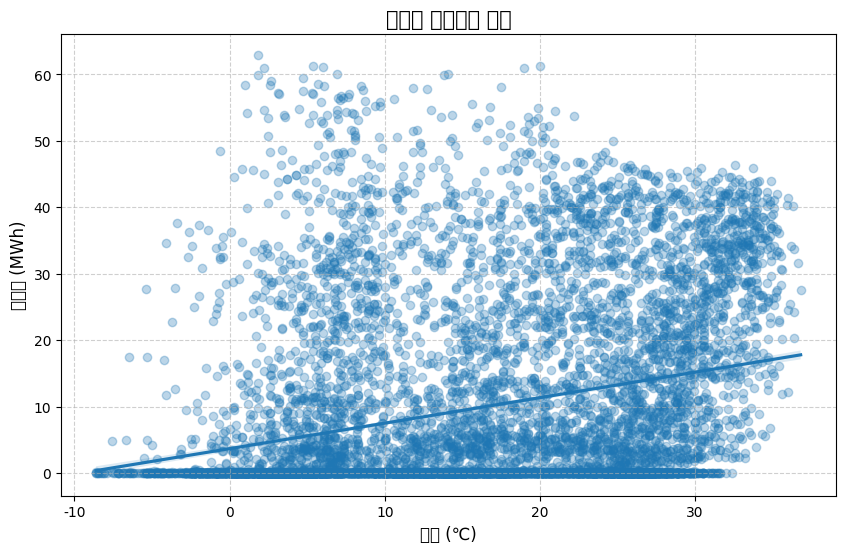

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # pandas import 추가

# 최종 병합된 데이터셋을 다시 로드합니다.
# 이 파일에는 '발전량' 컬럼이 포함되어 있습니다.
final_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv')

# '일시' 컬럼이 datetime 형식으로 되어 있지 않다면 변환합니다.
if '일시' in final_df.columns and not pd.api.types.is_datetime64_any_dtype(final_df['일시']):
    final_df['일시'] = pd.to_datetime(final_df['일시'])

# '기온'과 '발전량' 관계 시각화
plt.figure(figsize=(10, 6))
sns.regplot(x='기온', y='발전량', data=final_df, scatter_kws={'alpha':0.3})
plt.title('기온과 발전량의 관계', fontsize=15)
plt.xlabel('기온 (℃)', fontsize=12)
plt.ylabel('발전량 (MWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 시각화 결과:

- display_data에 따라 '기온과 발전량의 관계'를 보여주는 그래프가 출력됩니다.
- 이 그래프는 기온이 높아질수록 발전량도 대체로 증가하는 경향을 보이지만, 특정 기온 범위에서 발전량이 넓게 분포되어 있음을 알 수 있습니다.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.font_manager as fm
import pandas as pd

# 폰트 설정 (이전 셀에서 경고가 발생했으므로 다시 실행합니다)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm._load_fontmanager(try_read_cache = False) # 폰트 캐시 새로고침
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name() # 폰트 이름 적용
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지
print(f"설정된 폰트: {font_prop.get_name()}")

# 최종 병합된 데이터셋을 다시 로드 (혹시 모를 경우를 대비)
final_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv')

# '일시' 컬럼이 datetime 형식으로 되어 있지 않다면 변환합니다.
if '일시' in final_df.columns and not pd.api.types.is_datetime64_any_dtype(final_df['일시']):
    final_df['일시'] = pd.to_datetime(final_df['일시'])

설정된 폰트: NanumGothic


### 강수량과 발전량의 관계

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

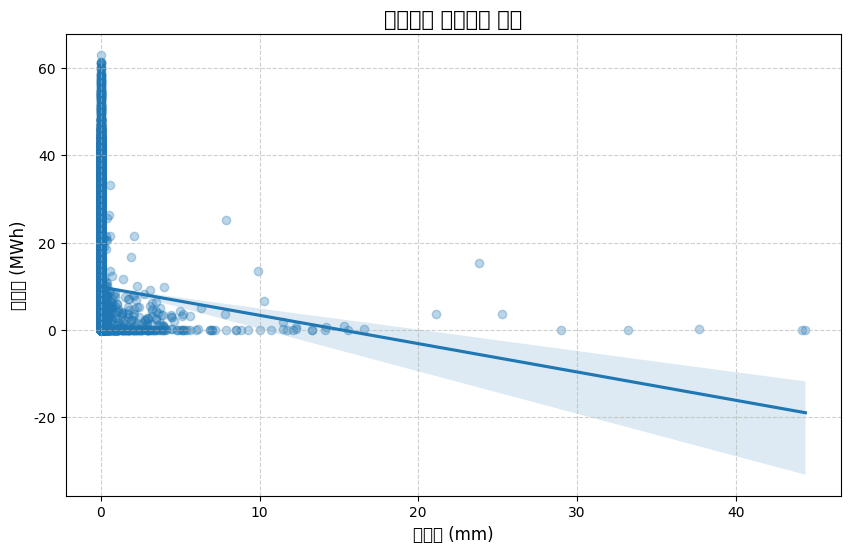

In [ ]:
# '강수량'과 '발전량' 관계 시각화
plt.figure(figsize=(10, 6))
sns.regplot(x='강수량', y='발전량', data=final_df, scatter_kws={'alpha':0.3})
plt.title('강수량과 발전량의 관계', fontsize=15)
plt.xlabel('강수량 (mm)', fontsize=12)
plt.ylabel('발전량 (MWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 시각화 결과 요약
## 강수량과 발전량의 관계:
- 그래프를 보면 강수량이 0인 경우가 대부분이며, 강수량이 발생할 경우 발전량은 전반적으로 낮거나 0에 가까운 경향을 보입니다.
- 이는 비가 오는 날은 일사량이 적어 태양광 발전량이 감소하기 때문입니다.

### 풍속과 발전량의 관계

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54413 (\N{HANGUL SYLLABLE PUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


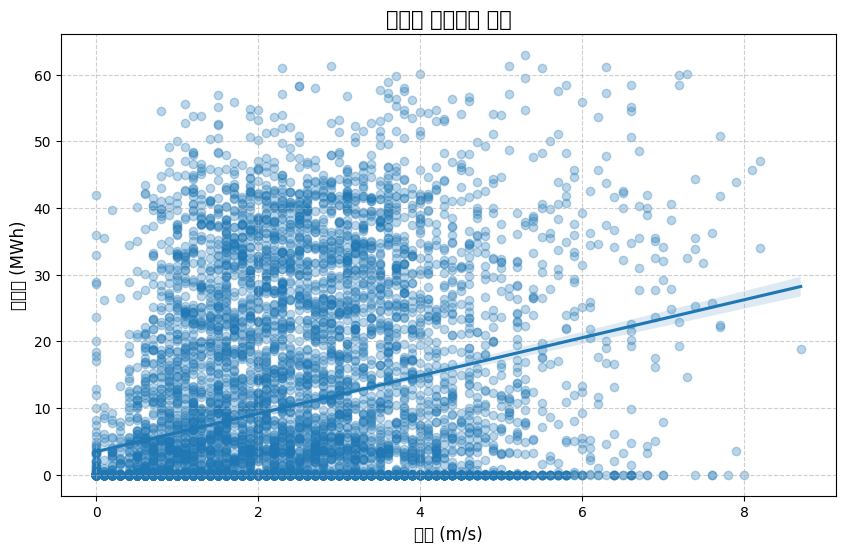

In [ ]:
# '풍속'과 '발전량' 관계 시각화
plt.figure(figsize=(10, 6))
sns.regplot(x='풍속', y='발전량', data=final_df, scatter_kws={'alpha':0.3})
plt.title('풍속과 발전량의 관계', fontsize=15)
plt.xlabel('풍속 (m/s)', fontsize=12)
plt.ylabel('발전량 (MWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 시각화 결과 요약
##풍속과 발전량의 관계:
- 풍속과 발전량 사이에는 뚜렷한 선형적인 관계를 찾기 어렵습니다.
- 풍속이 낮을 때부터 높을 때까지 다양한 발전량이 관측되며, 태양광 발전은 풍속의 영향을 직접적으로 크게 받지는 않는 것으로 보입니다.



### 습도와 발전량의 관계

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


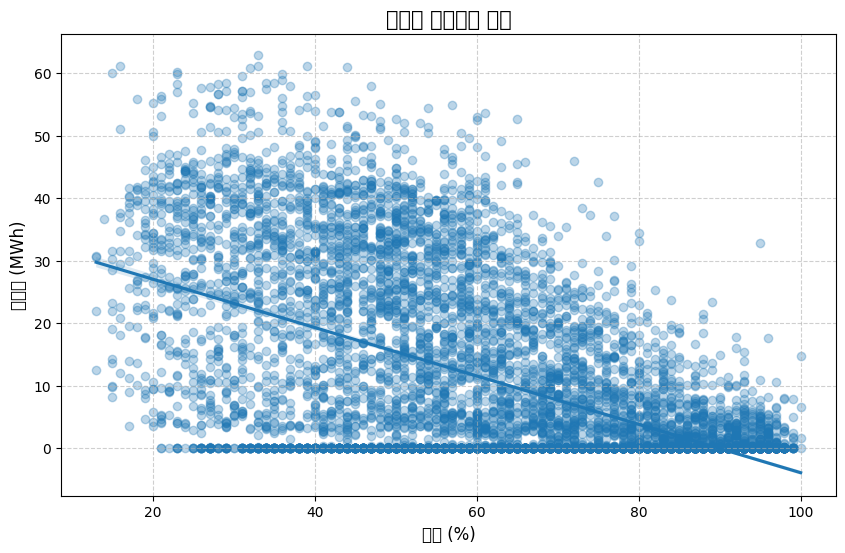

In [ ]:
# '습도'와 '발전량' 관계 시각화
plt.figure(figsize=(10, 6))
sns.regplot(x='습도', y='발전량', data=final_df, scatter_kws={'alpha':0.3})
plt.title('습도와 발전량의 관계', fontsize=15)
plt.xlabel('습도 (%)', fontsize=12)
plt.ylabel('발전량 (MWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 시각화 결과 요약
##습도와 발전량의 관계:
- 습도와 발전량 사이에도 명확한 선형 관계는 보이지 않습니다.
- 습도가 낮은 구간부터 높은 구간까지 발전량이 고르게 분포되어 있으며, 습도만으로는 발전량을 예측하기 어렵습니다.

### 일사량과 발전량의 관계

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


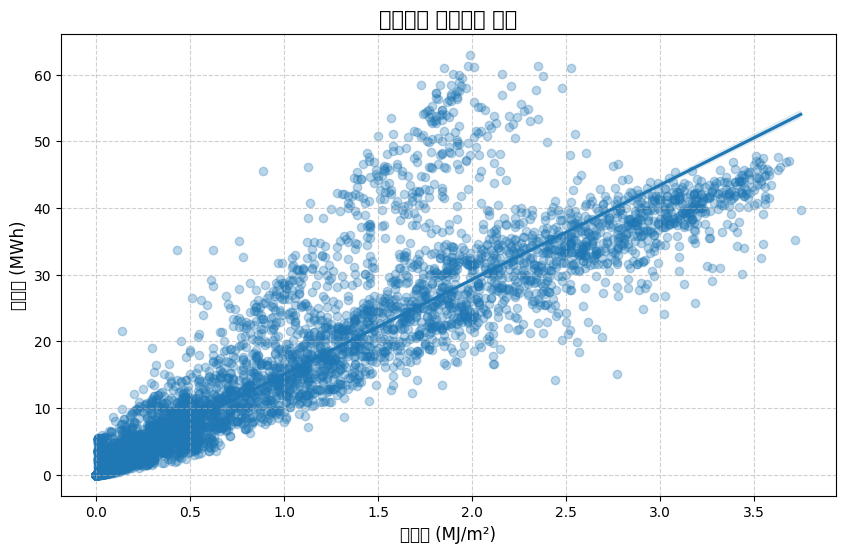

In [ ]:
# '일사량'과 '발전량' 관계 시각화
plt.figure(figsize=(10, 6))
sns.regplot(x='일사량', y='발전량', data=final_df, scatter_kws={'alpha':0.3})
plt.title('일사량과 발전량의 관계', fontsize=15)
plt.xlabel('일사량 (MJ/m²)', fontsize=12)
plt.ylabel('발전량 (MWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 시각화 결과 요약
## 일사량과 발전량의 관계:
- 일사량이 증가할수록 발전량도 뚜렷하게 증가하는 강한 양의 상관관계를 보입니다.
- 이는 태양광 발전의 핵심 요소인 일사량의 중요성을 명확히 보여줍니다.
- 일사량이 0일 때는 발전량도 0에 가깝게 나타납니다.

### 전운량과 발전량의 관계

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


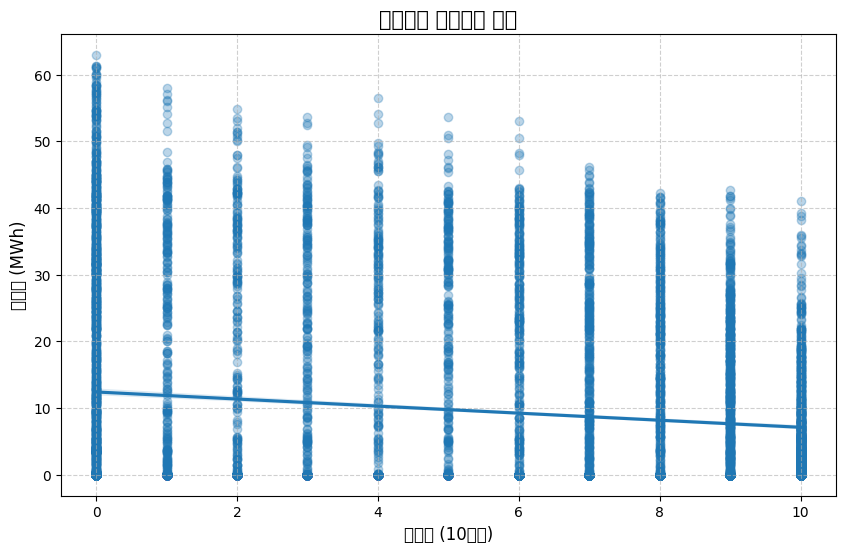

In [ ]:
# '전운량'과 '발전량' 관계 시각화
plt.figure(figsize=(10, 6))
sns.regplot(x='전운량', y='발전량', data=final_df, scatter_kws={'alpha':0.3})
plt.title('전운량과 발전량의 관계', fontsize=15)
plt.xlabel('전운량 (10분위)', fontsize=12)
plt.ylabel('발전량 (MWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 시각화 결과 요약
## 전운량과 발전량의 관계:
- 전운량(구름의 양)이 0에 가까울수록(맑은 날) 발전량이 높게 나타나고, 전운량이 증가할수록(구름이 많을수록) 발전량이 감소하는 경향을 보입니다.
- 이는 구름이 태양광을 가려 일사량을 줄이기 때문입니다.

### 월과 발전량의 관계 (Box Plot)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)

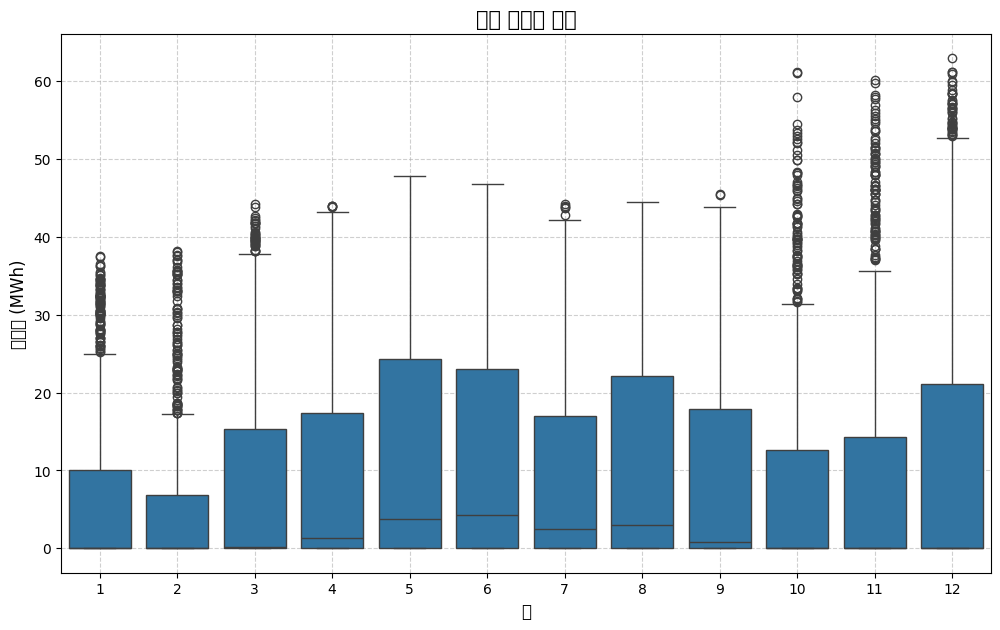

In [ ]:
# '월'과 '발전량' 관계 시각화 (범주형이므로 boxplot이 적합)
plt.figure(figsize=(12, 7))
sns.boxplot(x='월', y='발전량', data=final_df)
plt.title('월별 발전량 분포', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('발전량 (MWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 시각화 결과 요약
## 월별 발전량 분포 (Box Plot):
- 월별 발전량 분포를 보면 여름철(6월8월)에 발전량의 중앙값과 전체적인 분포가 높게 형성되는 것을 알 수 있습니다.
- 겨울철(12월2월)에는 발전량이 낮은 경향을 보입니다.
- 이는 일조 시간 및 일사량과 관련이 있습니다.

### 시간과 발전량의 관계 (Box Plot)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

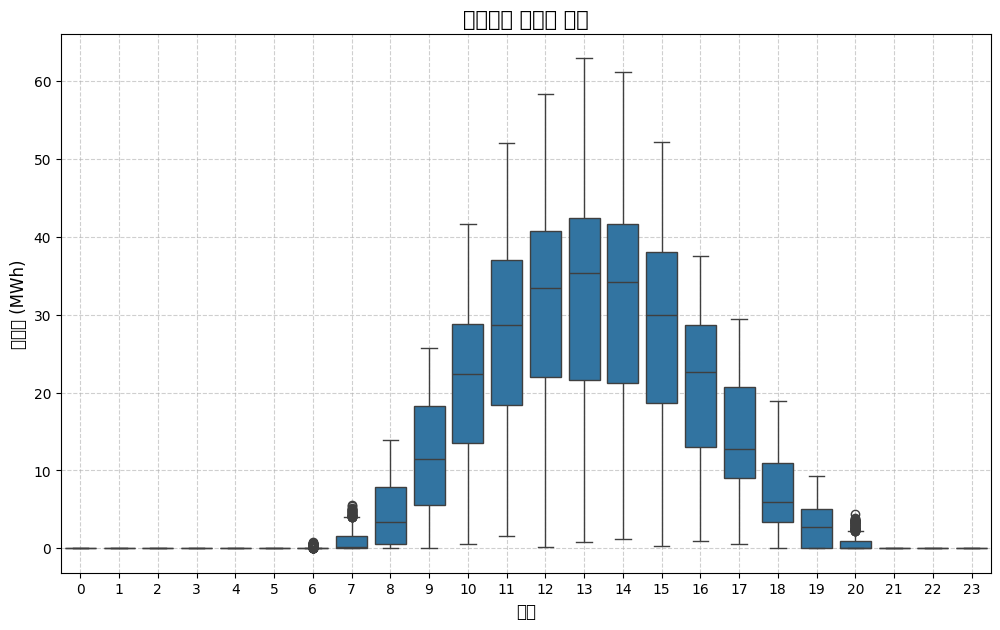

In [ ]:
# '시간'과 '발전량' 관계 시각화 (범주형이므로 boxplot이 적합)
plt.figure(figsize=(12, 7))
sns.boxplot(x='시간', y='발전량', data=final_df)
plt.title('시간대별 발전량 분포', fontsize=15)
plt.xlabel('시간', fontsize=12)
plt.ylabel('발전량 (MWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 시각화 결과 요약
## 시간대별 발전량 분포 (Box Plot):
- 시간대별 발전량 분포를 보면 해가 뜨고 지는 시간에 따라 발전량이 크게 달라지는 것을 알 수 있습니다.
- 주로 낮 시간대(대략 9시부터 17시 사이)에 발전량이 집중되며, 자정이나 이른 새벽, 늦은 밤에는 발전량이 거의 없거나 0에 가깝습니다.